In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
cd /content/drive/MyDrive

/content/drive/MyDrive


In [5]:
ls

 checkpoints/        __MACOSX/               taxi_drop/
'Colab Notebooks'/   nyc-taxi.h5             taxi_drop.zip
 KDD2022@            rain_impact_zones.png   w_texi_drop/


In [6]:
import numpy as np
import os
import torch
from torch.utils.data import TensorDataset, DataLoader

class StandardScaler:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def transform(self, data):
        return (data - self.mean) / self.std

    def inverse_transform(self, data):
        return (data * self.std) + self.mean

def load_dataset(dataset_dir, batch_size, valid_batch_size=None, test_batch_size=None):
    data = {}
    for category in ["train", "val", "test"]:
        cat_data = np.load(os.path.join(dataset_dir, category + ".npz"))
        data["x_" + category] = cat_data["x"]
        data["y_" + category] = cat_data["y"]

    scaler = StandardScaler(
        mean=data["x_train"][..., 0].mean(), std=data["x_train"][..., 0].std()
    )
    for category in ["train", "val", "test"]:
        data["x_" + category][..., 0] = scaler.transform(data["x_" + category][..., 0])

    train_ds = TensorDataset(torch.Tensor(data["x_train"]), torch.Tensor(data["y_train"]))
    val_ds   = TensorDataset(torch.Tensor(data["x_val"]),   torch.Tensor(data["y_val"]))
    test_ds  = TensorDataset(torch.Tensor(data["x_test"]),  torch.Tensor(data["y_test"]))

    loader_kwargs = dict(num_workers=4, pin_memory=True, prefetch_factor=2, persistent_workers=True)
    data["train_loader"] = DataLoader(train_ds, batch_size=batch_size,      shuffle=True,  **loader_kwargs)
    data["val_loader"]   = DataLoader(val_ds,   batch_size=valid_batch_size, shuffle=False, **loader_kwargs)
    data["test_loader"]  = DataLoader(test_ds,  batch_size=test_batch_size,  shuffle=False, **loader_kwargs)

    data["scaler"] = scaler
    return data


In [9]:
import torch
import torch.nn as nn
from transformers.models.gpt2.modeling_gpt2 import GPT2Model
from transformers import GPT2Config, GPT2Model

class TemporalEmbedding(nn.Module):
    def __init__(self, time, n_embd):
        super().__init__()
        self.day = time
        self.time_day = nn.Embedding(time, n_embd)
        self.time_week = nn.Embedding(7, n_embd)
        nn.init.xavier_uniform_(self.time_day.weight)
        nn.init.xavier_uniform_(self.time_week.weight)

    def forward(self, x):  # x: (B, P, N, C)
        device = x.device
        day_idx  = (x[:, -1, :, 1] * self.day).long().clamp(0, self.day - 1).to(device)
        day_embd = self.time_day(day_idx).transpose(1, 2).unsqueeze(-1)
        week_idx = x[:, -1, :, 2].long().clamp(0, 6).to(device)
        week_embd = self.time_week(week_idx).transpose(1, 2).unsqueeze(-1)
        return day_embd + week_embd


class SpatialEmbedding(nn.Module):
    def __init__(self, num_locations, n_embd):
        super().__init__()
        self.num_locations = num_locations
        self.location_embd = nn.Embedding(num_locations, n_embd)
        nn.init.xavier_uniform_(self.location_embd.weight)

    def forward(self, x):  # x: (B, P, N, C)
        B, device = x.shape[0], x.device
        indices = torch.arange(self.num_locations, device=device)
        node_emb = self.location_embd(indices)
        return node_emb.unsqueeze(0).expand(B, -1, -1).transpose(1, 2).unsqueeze(-1)


class TokenEmbedding(nn.Module):
    def __init__(self, input_dim, input_len=12, n_embd=256):
        super().__init__()
        self.tk_embd = nn.Conv2d(in_channels=input_dim * input_len, out_channels=n_embd, kernel_size=1)

    def forward(self, x):  # x: (B, P, N, C)
        B, P, N, C = x.shape
        x = x.permute(0, 3, 1, 2).reshape(B, -1, N)
        return self.tk_embd(x.unsqueeze(-1))  # (B, n_embd, N, 1)


# ─────────────────────────────────────────────────────────────────────────────
# Stage 1 — WACM + Dynamic Weather Gate
# ─────────────────────────────────────────────────────────────────────────────
class WeatherCrossAttention(nn.Module):
    """
    Weather-Adaptive Conditional Modulation with dynamic gate.

    [1] bias=False: zero rainfall → zero K/V → zero cross-attn output.
    [2] Location-adaptive query: spatial embedding modulates Q per node.
    [3] Temporal lag encoding: learnable pos-enc on weather timesteps.
    """
    def __init__(self, d_model=768, spatial_dim=256, input_len=12, n_heads=8):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads, self.d_head, self.input_len = n_heads, d_model // n_heads, input_len

        self.w_proj_k        = nn.Linear(1, d_model, bias=False)
        self.w_proj_v        = nn.Linear(1, d_model, bias=False)
        self.q_proj          = nn.Linear(d_model, d_model)
        self.spatial_mod     = nn.Linear(spatial_dim, d_model, bias=False)
        self.weather_pos_enc = nn.Embedding(input_len, d_model)
        self.out_proj        = nn.Linear(d_model, d_model, bias=False)
        self.norm            = nn.LayerNorm(d_model)
        self.scale           = self.d_head ** -0.5


    def forward(self, traffic_feat, x, spatial_embd):
        # traffic_feat: (B, N, d_model) | x: (B, P, N, C) | spatial_embd: (B, N, spatial_dim)
        B, N, D = traffic_feat.shape
        P, H, Dh = self.input_len, self.n_heads, self.d_head
        BN = B * N

        w_flat  = x[:, :, :, 3].permute(0, 2, 1).reshape(BN, P, 1)
        pos_enc = self.weather_pos_enc(torch.arange(P, device=x.device))
        k = self.w_proj_k(w_flat) + pos_enc
        v = self.w_proj_v(w_flat) + pos_enc
        # k = self.w_proj_k(w_flat) 
        # v = self.w_proj_v(w_flat)

        q = (self.q_proj(traffic_feat) + self.spatial_mod(spatial_embd)).reshape(BN, 1, D)
        
        # q = (self.q_proj(traffic_feat)).reshape(BN, 1, D)
        q = q.view(BN, 1, H, Dh).transpose(1, 2)
        k = k.view(BN, P, H, Dh).transpose(1, 2)
        v = v.view(BN, P, H, Dh).transpose(1, 2)

        attn = torch.softmax(q @ k.transpose(-2, -1) * self.scale, dim=-1)  # (BN, H, 1, P)
        out  = (attn @ v).squeeze(2).reshape(BN, D)
        out  = self.out_proj(out).view(B, N, D)                              # (B, N, D)


        # return self.norm(traffic_feat + gate * out), attn.detach(), gate.detach()
        return self.norm(traffic_feat + out), attn.detach()


# ─────────────────────────────────────────────────────────────────────────────
# Stage 2 — Weather-Adaptive LayerNorm inside GPT-2
# ─────────────────────────────────────────────────────────────────────────────
class WeatherEncoder(nn.Module):
    def __init__(self, input_len, d_weather=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_len, d_weather),
            nn.GELU(),
            nn.Linear(d_weather, d_weather)
        )

    def forward(self, x):  # x: (B, P, N, C)
        weather = x[:, :, :, 3].mean(dim=2) # 取mean
        return self.encoder(weather)  # (B, d_weather)


# class AdaLN(nn.Module):
#     """DiT-style AdaLN. Zero-initialized: starts as standard LN."""
#     def __init__(self, d_model=768, d_cond=128):
#         super().__init__()
#         self.norm = nn.LayerNorm(d_model, elementwise_affine=False)
#         self.proj = nn.Linear(d_cond, 2 * d_model)
#         nn.init.zeros_(self.proj.weight)
#         nn.init.zeros_(self.proj.bias)

#     def forward(self, x, cond):  # x: (B, N, D), cond: (B, d_cond)
#         dg, db = self.proj(cond).unsqueeze(1).chunk(2, dim=-1)
#         return (1 + dg) * self.norm(x) + db

# 升级版本的AdaLN    
class AdaLN(nn.Module):
    """DiT-style AdaLN with MLP projector (SiLU activation)."""
    def __init__(self, d_model=768, d_cond=128):
        super().__init__()
        self.norm = nn.LayerNorm(d_model, elementwise_affine=False)
        self.proj = nn.Sequential(
            nn.Linear(d_cond, d_cond),
            nn.SiLU(),
            nn.Linear(d_cond, 2 * d_model)
        )
        # 零初始化最后一层，保证训练初期行为和标准 LN 一致
        nn.init.zeros_(self.proj[-1].weight)
        nn.init.zeros_(self.proj[-1].bias)

    def forward(self, x, cond):  # x: (B, N, D), cond: (B, d_cond)
        dg, db = self.proj(cond).unsqueeze(1).chunk(2, dim=-1)
        return (1 + dg) * self.norm(x) + db



class WeatherAdaPFA(nn.Module):
    """GPT-2 PFA with AdaLN replacing ln_1/ln_2 at every layer."""
    def __init__(self, gpt_layers=6, U=1, d_weather=128, input_len=12):
        super().__init__()
        self.gpt2 = GPT2Model.from_pretrained("gpt2")
        # config = GPT2Config()
        # self.gpt2 = GPT2Model(config)
        self.gpt2.h = self.gpt2.h[:gpt_layers]

        for layer_idx, layer in enumerate(self.gpt2.h):
            for name, param in layer.named_parameters():
                if layer_idx < gpt_layers - U:
                    param.requires_grad = False
                    # param.requires_grad = "ln" in name  
                else:
                    # param.requires_grad = "attn"  in name
                    # param.requires_grad = "mlp" not in name 
                    param.requires_grad = True 

        self.weather_encoder = WeatherEncoder(input_len, d_weather)
        self.ada_ln1 = nn.ModuleList([AdaLN(768, d_weather) for _ in range(gpt_layers)])
        self.ada_ln2 = nn.ModuleList([AdaLN(768, d_weather) for _ in range(gpt_layers)])

    def forward(self, x, weather_input):
        # x: (B, N, 768) | weather_input: (B, P, N, C)
        cond = self.weather_encoder(weather_input)  # (B, d_weather)
        position_ids = torch.arange(x.shape[1], device=x.device).unsqueeze(0)
        hidden = self.gpt2.drop(x + self.gpt2.wpe(position_ids))

        # hidden = self.gpt2.drop(x)
        
        for i, block in enumerate(self.gpt2.h):
            residual = hidden
            hidden = self.ada_ln1[i](hidden, cond)
            # hidden = self.gpt2.h[i].ln_1(hidden)
            hidden = residual + block.attn(hidden)[0]
            residual = hidden
            hidden = self.ada_ln2[i](hidden, cond)
            # hidden = self.gpt2.h[i].ln_2(hidden)
            hidden = residual + block.mlp(hidden)

        return self.gpt2.ln_f(hidden)


# ─────────────────────────────────────────────────────────────────────────────
# Main Model
# ─────────────────────────────────────────────────────────────────────────────
class ST_LLM(nn.Module):
    def __init__(self, batch_size=32, num_nodes=266, n_embd = 256, input_len=12, output_len=12, gpt_layers=6, U=1, d_weather=128):
        super().__init__()
        self.batch_size = batch_size
        self.num_nodes  = num_nodes
        self.input_len  = input_len
        self.output_len = output_len
        self.time       = 48
        self.n_embd     = n_embd
        self.gpt_embd   = 768

        self.time_embd    = TemporalEmbedding(self.time, self.n_embd)
        self.spatial_embd = SpatialEmbedding(self.num_nodes, self.n_embd)
        self.token_embd   = TokenEmbedding(input_dim=3, input_len=self.input_len, n_embd=self.n_embd)

        self.feature_fuse = nn.Conv2d(in_channels=3*self.n_embd, out_channels=self.gpt_embd, kernel_size=1)

        # self.dropout = nn.Dropout(0.1)

        self.weather_cross_attn = WeatherCrossAttention(
            d_model=self.gpt_embd, spatial_dim=self.n_embd, input_len=self.input_len)

        self.pfa = WeatherAdaPFA(
            gpt_layers=gpt_layers, U=U, d_weather=d_weather, input_len=self.input_len)

        self.regression_layer = nn.Conv2d(
            in_channels=self.gpt_embd, out_channels=self.output_len, kernel_size=1)

    def forward(self, history_data, return_attn=True):  # (B, P, N, C)
        input_data = history_data
        B, P, N, C = input_data.shape

        time_embd    = self.time_embd(input_data)
        spatial_embd = self.spatial_embd(input_data)
        token_embd   = self.token_embd(input_data[:, :, :, :3]) #没有加入weather info

        embd_feature = torch.cat([token_embd, time_embd, spatial_embd], dim=1)
       
        data_feature = self.feature_fuse(embd_feature).squeeze(-1).permute(0, 2, 1)
        
        # data_feature = self.dropout(data_feature)

        spatial_flat = spatial_embd.squeeze(-1).permute(0, 2, 1)  # (B, N, n_embd)

        data_feature, weather_attn = self.weather_cross_attn(
             data_feature, input_data, spatial_flat)

        pfa_out = self.pfa(data_feature, input_data)

        pred = self.regression_layer(
            pfa_out.permute(0, 2, 1).unsqueeze(-1)).squeeze(-1)   # (B, output_len, N)

        if return_attn:
            # weather_attn: (B*N, H, 1, P) — which lag matters per node
            # weather_gate: (B, N, 1)       — per-node weather sensitivity
            return pred, weather_attn
        return pred


In [10]:
# train
import torch
import torch.nn as nn
import numpy as np
import time
import os
import logging
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

torch.manual_seed(313)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using Device: {device}")

# ── 超参数 ────────────────────────────────────────────────────────────────────
batch_size  = 64
lrate       = 5e-4
wdecay      = 5e-5
epochs      = 300
num_nodes   = 266
input_len   = 12
output_len  = 12
gpt_layers  = 7
U           = 5
d_weather = 128
n_embd = 256
dataset_dir = "w_texi_drop"
SAVE_DIR    = "./checkpoints"
SAVE_AFTER  = 40       # 40 轮以后才开始保存最优权重
T_0         = 50    # 每 50 轮重启一次，300 轮共 6 次
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Logger ────────────────────────────────────────────────────────────────────
def get_logger(log_path):
    logger = logging.getLogger("stw_llm")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    fmt = logging.Formatter("%(asctime)s  %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
    fh = logging.FileHandler(log_path, mode="a", encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)
    sh = logging.StreamHandler()
    sh.setFormatter(fmt)
    logger.addHandler(sh)
    return logger

# ── 指标计算 ──────────────────────────────────────────────────────────────────
def calc_metrics(pred, real):
    mae  = np.mean(np.abs(pred - real))
    rmse = np.sqrt(np.mean((pred - real) ** 2))
    mask = real != 0
    mape = np.mean(np.abs((pred[mask] - real[mask]) / real[mask])) * 100
    wape = np.sum(np.abs(pred - real)) / np.sum(np.abs(real)) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape, "wape": wape}

# ── Trainer ───────────────────────────────────────────────────────────────────
class trainer:
    def __init__(self, scaler, batch_size, learning_rate, wdecay,
                 num_nodes, input_len, output_len, gpt_layers, U):
        self.scaler     = scaler
        self.amp_scaler = GradScaler()
        self.model = ST_LLM(batch_size=batch_size, num_nodes=num_nodes, n_embd=n_embd,
                            input_len=input_len, output_len=output_len,
                            gpt_layers=gpt_layers, U=U, d_weather= d_weather).to(device)
        self.model = torch.compile(self.model)   # PyTorch 2.0+ 图优化
        self.optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.model.parameters()),
            lr=learning_rate, weight_decay=wdecay)
   
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=T_0, T_mult=1, eta_min=1e-6)
        
        self.criterion = nn.MSELoss() 

    def train_loop(self, x, y):
        self.model.train()
        self.optimizer.zero_grad(set_to_none=True)
        with autocast():
            output = self.model(x, return_attn=False)
            pred   = self.scaler.inverse_transform(output).unsqueeze(-1)
            loss   = self.criterion(pred, y)
        self.amp_scaler.scale(loss).backward()
        self.amp_scaler.step(self.optimizer)
        self.amp_scaler.update()
        return loss.item()

    def eval_loop(self, x, y):
        self.model.eval()
        with torch.no_grad(), autocast():
            output = self.model(x, return_attn=False)
            pred   = self.scaler.inverse_transform(output).unsqueeze(-1)
            loss   = self.criterion(pred, y)
        return loss.item(), pred, y

# ── 评估一整个 loader ─────────────────────────────────────────────────────────
def evaluate(engine, loader):
    mse_list, preds, reals = [], [], []
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        mse, p, r = engine.eval_loop(x_batch, y_batch)
        mse_list.append(mse)
        preds.append(p)
        reals.append(r)
    pred_all = torch.cat(preds).cpu().numpy()   # 一次性转换，减少 CPU 开销
    real_all = torch.cat(reals).cpu().numpy()
    metrics  = calc_metrics(pred_all, real_all)
    metrics["mse"] = np.mean(mse_list)
    return metrics

# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    log_path  = os.path.join(SAVE_DIR, "train.log")
    ckpt_path = os.path.join(SAVE_DIR, "best_model.pt")
    logger    = get_logger(log_path)

    dataloader = load_dataset(dataset_dir, batch_size=batch_size,
                              valid_batch_size=batch_size, test_batch_size=batch_size)
    engine = trainer(scaler=dataloader["scaler"], batch_size=batch_size,
                     learning_rate=lrate, wdecay=wdecay,
                     num_nodes=num_nodes, input_len=input_len, output_len=output_len,
                     gpt_layers=gpt_layers, U=U)

    best_val_mae = float("inf")
    logger.info(f"gpt layer {gpt_layers} U {U} n_embd{n_embd} ")
    logger.info(f"Training started  |  epochs={epochs}  lr={lrate}  wd={wdecay}")
    logger.info(f"Checkpoint dir: {SAVE_DIR}  |  save_after={SAVE_AFTER}")
    logger.info(f"{'Epoch':>6}  {'TrainMSE':>10}  {'MAE':>8}  {'RMSE':>8}  {'MAPE%':>8}  {'WAPE%':>8}  {'Time':>7}  Note")

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # --- train ---
        train_losses = []
        train_bar = tqdm(dataloader["train_loader"],
                         desc=f"Epoch {epoch:>3}/{epochs} [train]",
                         leave=False, dynamic_ncols=True)
        for x_batch, y_batch in train_bar:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss = engine.train_loop(x_batch, y_batch)
            train_losses.append(loss)
            train_bar.set_postfix(loss=f"{loss:.4f}")

        # --- val ---
        val_m      = evaluate(engine, dataloader["val_loader"])
        epoch_time = time.time() - t0

        # --- 20 轮以后保存最优权重（以 MAE 为准）---
        tag = ""
        if epoch > SAVE_AFTER and val_m["mae"] < best_val_mae:
            best_val_mae = val_m["mae"]
            torch.save(engine.model.state_dict(), ckpt_path)
            tag = "★ best"

        logger.info(
            f"{epoch:>6}/{epochs}  "
            f"{np.mean(train_losses):>10.4f}  "
            f"{val_m['mae']:>8.4f}  "
            f"{val_m['rmse']:>8.4f}  "
            f"{val_m['mape']:>8.2f}  "
            f"{val_m['wape']:>8.2f}  "
            f"{epoch_time:>6.1f}s  {tag}"
        )

    # ── 最终 Test 评估 ────────────────────────────────────────────────────────
    logger.info("=" * 70)
    logger.info(f"Loading best checkpoint  (best val MAE={best_val_mae:.4f})")
    engine.model.load_state_dict(torch.load(ckpt_path, map_location=device))

    test_m = evaluate(engine, dataloader["test_loader"])
    logger.info(
        f"[TEST]  MAE={test_m['mae']:.4f}  RMSE={test_m['rmse']:.4f}  "
        f"MAPE={test_m['mape']:.2f}%  WAPE={test_m['wape']:.2f}%  MSE={test_m['mse']:.4f}"
    )
    logger.info("=" * 70)

if __name__ == "__main__":
    main()


Using Device: cuda


/tmp/ipykernel_9795/1170258755.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.amp_scaler = GradScaler()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-02 02:46:08  gpt layer 7 U 5 n_embd256 
INFO:stw_llm:gpt layer 7 U 5 n_embd256 
2026-05-02 02:46:08  Training started  |  epochs=300  lr=0.0005  wd=5e-05
INFO:stw_llm:Training started  |  epochs=300  lr=0.0005  wd=5e-05
2026-05-02 02:46:08  Checkpoint dir: ./checkpoints  |  save_after=40
INFO:stw_llm:Checkpoint dir: ./checkpoints  |  save_after=40
2026-05-02 02:46:08   Epoch    TrainMSE       MAE      RMSE     MAPE%     WAPE%     Time  Note
INFO:stw_llm: Epoch    TrainMSE       MAE      RMSE     MAPE%     WAPE%     Time  Note
Epoch   1/300 [train]:   0%|          | 0/41 [00:00<?, ?it/s]/tmp/ipykernel_9795/1170258755.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.

In [10]:
# val 和 test 的流量分布差异
import numpy as np

val_data   = np.load("w_texi_drop/val.npz")
test_data  = np.load("w_texi_drop/test.npz")

print(f"Val  y: mean={val_data['y'][...,0].mean():.3f}  std={val_data['y'][...,0].std():.3f}")
print(f"Test y: mean={test_data['y'][...,0].mean():.3f}  std={test_data['y'][...,0].std():.3f}")

# 降雨比例
val_rain  = (val_data['x'][...,3] > 0).mean()
test_rain = (test_data['x'][...,3] > 0).mean()
print(f"Val  rain ratio: {val_rain:.3f}")
print(f"Test rain ratio: {test_rain:.3f}")


Val  y: mean=25.264  std=36.857
Test y: mean=25.014  std=37.304
Val  rain ratio: 0.113
Test rain ratio: 0.081


# 推理+预测可视化

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: ./checkpoints/best_model.pt


/tmp/ipykernel_9795/2248140280.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[ALL]    MAE=4.8836  RMSE=8.6100  MAPE=35.99%  WAPE=19.52%
[RAINY]  MAE=5.0944                   MAPE=36.55%  WAPE=19.03%
[DRY]    MAE=4.8426
Rainy samples: 135  |  Dry samples: 724


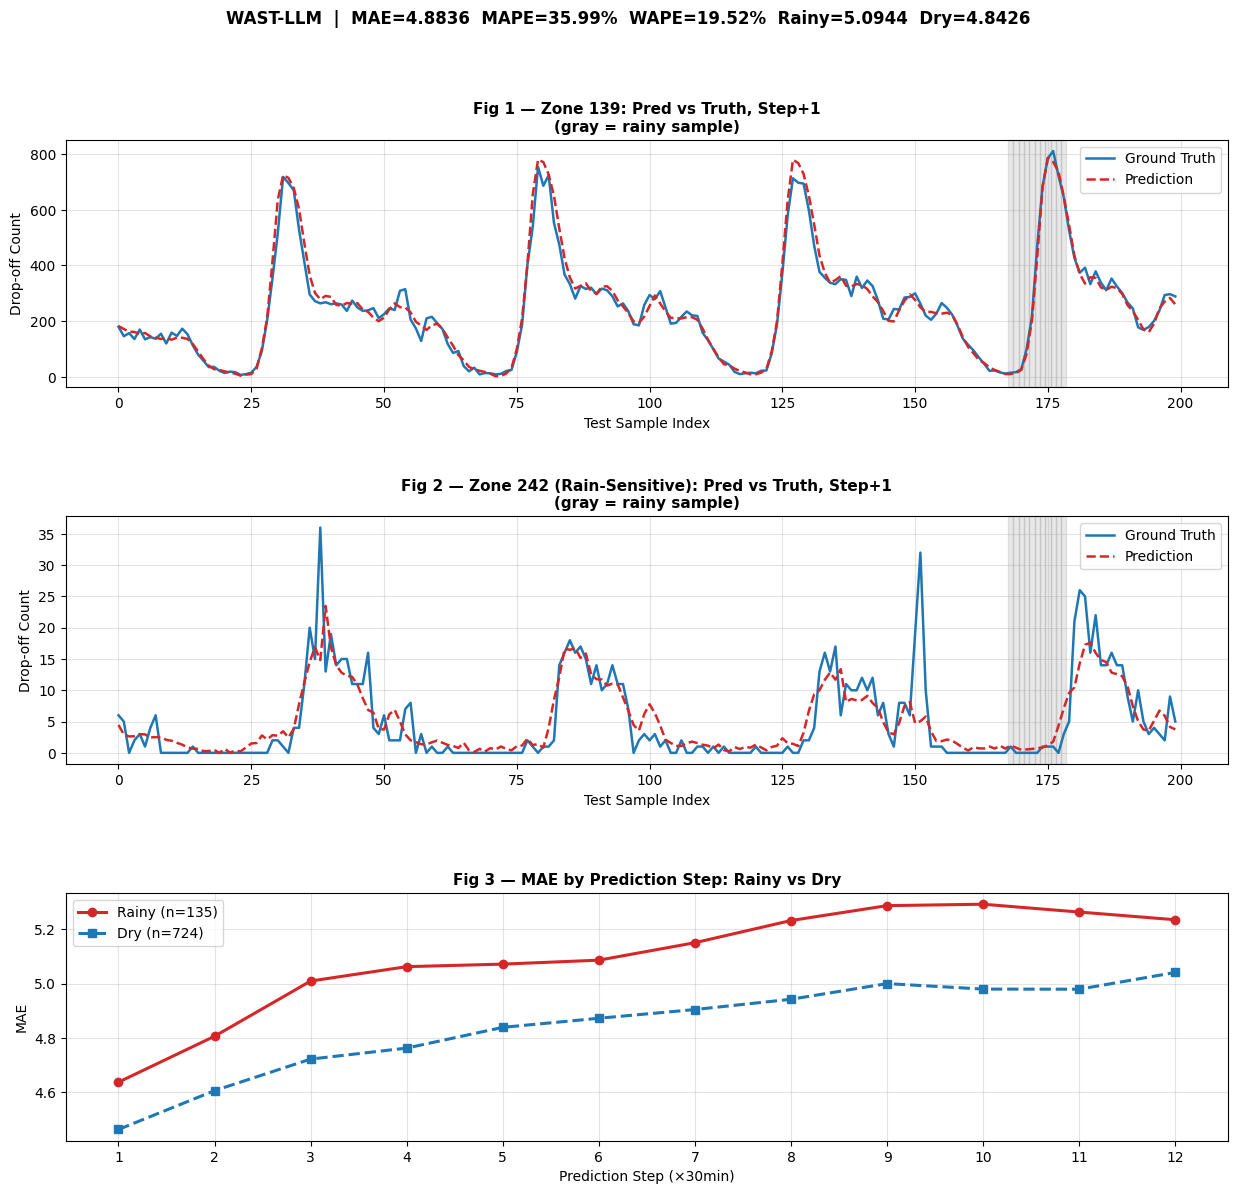

Saved: ./checkpoints/inference_vis.png

[Fig 3 Data Points — MAE by Prediction Step]
 Step   Rainy MAE     Dry MAE   Diff(R-D)
  +01        4.6372      4.4631     +0.1742
  +02        4.8062      4.6060     +0.2002
  +03        5.0094      4.7220     +0.2873
  +04        5.0623      4.7625     +0.2998
  +05        5.0717      4.8389     +0.2328
  +06        5.0862      4.8724     +0.2138
  +07        5.1505      4.9045     +0.2460
  +08        5.2321      4.9423     +0.2898
  +09        5.2869      4.9999     +0.2870
  +10        5.2922      4.9798     +0.3124
  +11        5.2633      4.9793     +0.2840
  +12        5.2350      5.0409     +0.1941


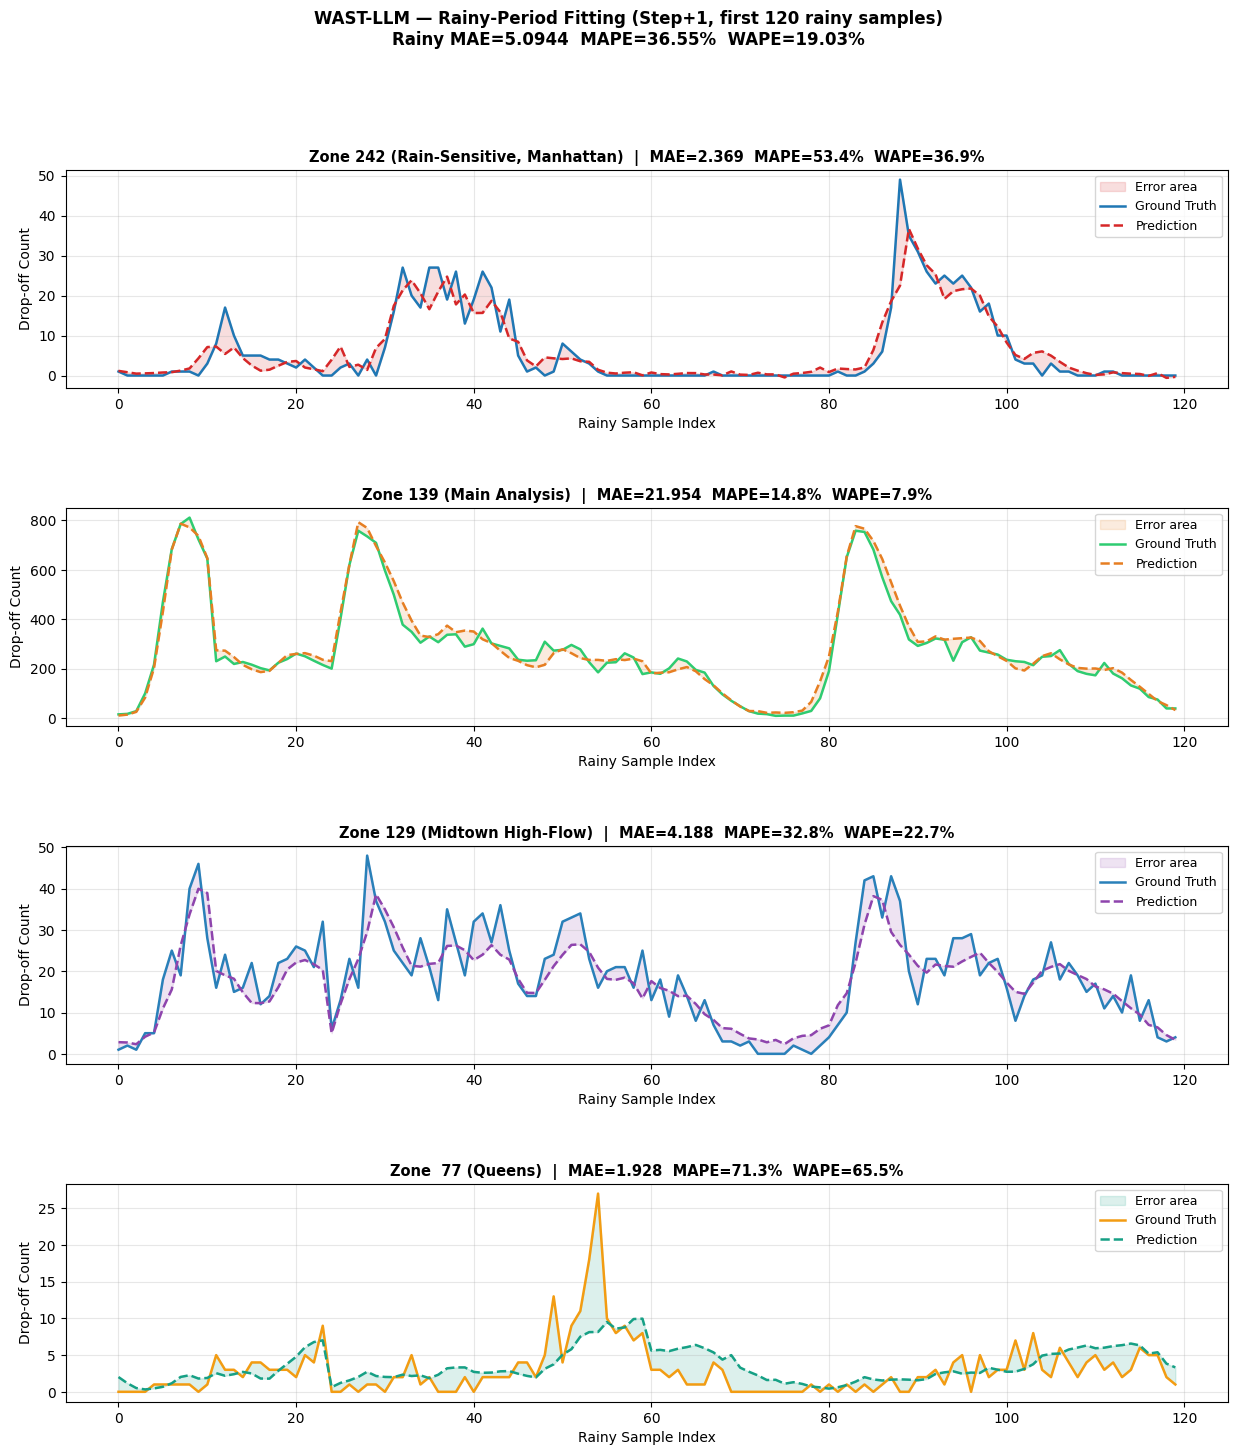

Saved: ./checkpoints/wastllm_rainy_zones.png

[Rainy-Period Zone Metrics  (Step+1, all rainy samples)]
    Zone       MAE     MAPE%     WAPE%
     242     2.2219     58.33     38.60
     139    22.0553     16.48      7.89
     129     4.0418     35.72     22.78
      77     1.8613     70.01     68.28


In [11]:
# ── Inference & Visualization ─────────────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(313)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size  = 16
num_nodes   = 266
input_len   = 12
output_len  = 12
gpt_layers  = 7
U           = 5
d_weather   = 128
n_embd      = 256
dataset_dir = "w_texi_drop"
SAVE_DIR    = "./checkpoints"
CKPT_PATH   = "./checkpoints/best_model.pt"

# ── 加载模型 ──────────────────────────────────────────────────────────────────
dataloader = load_dataset(dataset_dir, batch_size=batch_size,
                          valid_batch_size=batch_size, test_batch_size=batch_size)
scaler = dataloader["scaler"]

model = ST_LLM(batch_size=batch_size, num_nodes=num_nodes, n_embd=n_embd,
               input_len=input_len, output_len=output_len,
               gpt_layers=gpt_layers, U=U, d_weather=d_weather).to(device)
state_dict = torch.load(CKPT_PATH, map_location=device)
state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.eval()
print(f"Loaded: {CKPT_PATH}")

# ── 全量推理 ──────────────────────────────────────────────────────────────────
all_preds, all_reals, all_rain_cov = [], [], []

with torch.no_grad():
    for x_batch, y_batch in dataloader["test_loader"]:
        x_batch = x_batch.to(device)
        # x_batch[:,:,:,3] = 0
        with torch.cuda.amp.autocast():
            out = model(x_batch, return_attn=False)
        pred     = scaler.inverse_transform(out).cpu().numpy()
        real     = y_batch.squeeze(-1).numpy()
        rain_cov = (x_batch[:, :, :, 3] > 0).float().mean(dim=(1, 2)).cpu().numpy()
        all_preds.append(pred)
        all_reals.append(real)
        all_rain_cov.append(rain_cov)

preds     = np.concatenate(all_preds,    axis=0)
reals     = np.concatenate(all_reals,    axis=0)
rain_covs = np.concatenate(all_rain_cov, axis=0)

# ── 分组 & 指标 ───────────────────────────────────────────────────────────────
rainy_mask = rain_covs > 0.1
dry_mask   = rain_covs == 0.0
rainy_idx  = np.where(rainy_mask)[0]   # 雨天样本的全局索引

mae_all  = np.mean(np.abs(preds - reals))
rmse_all = np.sqrt(np.mean((preds - reals) ** 2))
mask_nz  = reals != 0
mape_all = np.mean(np.abs((preds[mask_nz] - reals[mask_nz]) / reals[mask_nz])) * 100
wape_all = np.sum(np.abs(preds - reals)) / np.sum(np.abs(reals)) * 100

mae_rain = np.mean(np.abs(preds[rainy_mask] - reals[rainy_mask])) if rainy_mask.sum() > 0 else float('nan')
mae_dry  = np.mean(np.abs(preds[dry_mask]   - reals[dry_mask]))   if dry_mask.sum()   > 0 else float('nan')
mask_r_nz = reals[rainy_mask] != 0
mape_rain = np.mean(np.abs((preds[rainy_mask][mask_r_nz] - reals[rainy_mask][mask_r_nz])
                            / reals[rainy_mask][mask_r_nz])) * 100 if rainy_mask.sum() > 0 else float('nan')
wape_rain = (np.sum(np.abs(preds[rainy_mask] - reals[rainy_mask]))
             / np.sum(np.abs(reals[rainy_mask]))) * 100             if rainy_mask.sum() > 0 else float('nan')

print("=" * 65)
print(f"[ALL]    MAE={mae_all:.4f}  RMSE={rmse_all:.4f}  MAPE={mape_all:.2f}%  WAPE={wape_all:.2f}%")
print(f"[RAINY]  MAE={mae_rain:.4f}                   MAPE={mape_rain:.2f}%  WAPE={wape_rain:.2f}%")
print(f"[DRY]    MAE={mae_dry:.4f}")
print(f"Rainy samples: {rainy_mask.sum()}  |  Dry samples: {dry_mask.sum()}")
print("=" * 65)

# ── Fig 1-3：原有总览图 ───────────────────────────────────────────────────────
zone_a = 139
zone_b = 242
n_show = 200

fig, axs = plt.subplots(3, 1, figsize=(15, 13))
plt.subplots_adjust(hspace=0.52)
fig.suptitle(
    f'WAST-LLM  |  MAE={mae_all:.4f}  MAPE={mape_all:.2f}%  WAPE={wape_all:.2f}%  '
    f'Rainy={mae_rain:.4f}  Dry={mae_dry:.4f}',
    fontsize=12, fontweight='bold')

for ax, zone_id, title in [
    (axs[0], zone_a, f'Fig 1 — Zone {zone_a}: Pred vs Truth, Step+1'),
    (axs[1], zone_b, f'Fig 2 — Zone {zone_b} (Rain-Sensitive): Pred vs Truth, Step+1'),
]:
    t = np.arange(n_show)
    ax.plot(t, reals[:n_show, 0, zone_id], color='#1f77b4', lw=1.8, label='Ground Truth')
    ax.plot(t, preds[:n_show, 0, zone_id], color='#d62728', lw=1.8, ls='--', label='Prediction')
    for i in range(n_show):
        if rainy_mask[i]:
            ax.axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.18)
    ax.set_title(f'{title}\n(gray = rainy sample)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Sample Index'); ax.set_ylabel('Drop-off Count')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.35)

ax = axs[2]
steps          = np.arange(1, output_len + 1)
rain_mae_steps = [np.mean(np.abs(preds[rainy_mask, s, :] - reals[rainy_mask, s, :])) for s in range(output_len)]
dry_mae_steps  = [np.mean(np.abs(preds[dry_mask,   s, :] - reals[dry_mask,   s, :])) for s in range(output_len)]
ax.plot(steps, rain_mae_steps, color='#d62728', lw=2.2, marker='o', label=f'Rainy (n={rainy_mask.sum()})')
ax.plot(steps, dry_mae_steps,  color='#1f77b4', lw=2.2, marker='s', ls='--', label=f'Dry (n={dry_mask.sum()})')
ax.set_title('Fig 3 — MAE by Prediction Step: Rainy vs Dry', fontsize=11, fontweight='bold')
ax.set_xlabel('Prediction Step (×30min)'); ax.set_ylabel('MAE')
ax.set_xticks(steps); ax.legend(fontsize=10); ax.grid(True, alpha=0.35)

plt.savefig('./checkpoints/inference_vis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./checkpoints/inference_vis.png")

# ── Fig 3 数据点打印 ──────────────────────────────────────────────────────────
print("\n[Fig 3 Data Points — MAE by Prediction Step]")
print(f"{'Step':>5}  {'Rainy MAE':>10}  {'Dry MAE':>10}  {'Diff(R-D)':>10}")
for s in range(output_len):
    diff = rain_mae_steps[s] - dry_mae_steps[s]
    print(f"  +{s+1:02d}    {rain_mae_steps[s]:>10.4f}  {dry_mae_steps[s]:>10.4f}  {diff:>+10.4f}")

# ── Fig 4：雨天时段各区域拟合（只展示雨天样本）─────────────────────────────
# 选区依据：
#   Zone 242 — 已知雨敏感高流量区（Manhattan 市中心）
#   Zone 139 — 主要分析区
#   Zone 129 — 中城核心高流量区（Grand Central 附近）
#   Zone  77 — 皇后区，与曼哈顿地理隔离，降雨反应模式不同
RAIN_ZONES = [242, 139, 129, 77]
RAIN_ZONE_LABELS = {
    242: 'Zone 242 (Rain-Sensitive, Manhattan)',
    139: 'Zone 139 (Main Analysis)',
    129: 'Zone 129 (Midtown High-Flow)',
     77: 'Zone  77 (Queens)',
}

n_rain_show = min(120, len(rainy_idx))
show_idx    = rainy_idx[:n_rain_show]
t_rain      = np.arange(n_rain_show)

fig2, axs2 = plt.subplots(len(RAIN_ZONES), 1, figsize=(15, 4 * len(RAIN_ZONES)))
plt.subplots_adjust(hspace=0.55)
fig2.suptitle(
    f'WAST-LLM — Rainy-Period Fitting (Step+1, first {n_rain_show} rainy samples)\n'
    f'Rainy MAE={mae_rain:.4f}  MAPE={mape_rain:.2f}%  WAPE={wape_rain:.2f}%',
    fontsize=12, fontweight='bold')

colors_pred  = ['#d62728', '#e67e22', '#8e44ad', '#16a085']
colors_truth = ['#1f77b4', '#2ecc71', '#2980b9', '#f39c12']

for i, (zone_id, c_pred, c_truth) in enumerate(zip(RAIN_ZONES, colors_pred, colors_truth)):
    ax = axs2[i]
    truth_zone = reals[show_idx, 0, zone_id]
    pred_zone  = preds[show_idx, 0, zone_id]
    err        = np.abs(pred_zone - truth_zone)

    ax.fill_between(t_rain, truth_zone, pred_zone,
                    alpha=0.15, color=c_pred, label='Error area')
    ax.plot(t_rain, truth_zone, color=c_truth, lw=1.8, label='Ground Truth')
    ax.plot(t_rain, pred_zone,  color=c_pred,  lw=1.8, ls='--', label='Prediction')

    zone_mae  = err.mean()
    mask_z_nz = truth_zone != 0
    zone_mape = np.mean(np.abs((pred_zone[mask_z_nz] - truth_zone[mask_z_nz])
                                / truth_zone[mask_z_nz])) * 100 if mask_z_nz.sum() > 0 else float('nan')
    zone_wape = np.sum(err) / np.sum(np.abs(truth_zone)) * 100

    ax.set_title(
        f'{RAIN_ZONE_LABELS[zone_id]}  |  MAE={zone_mae:.3f}  MAPE={zone_mape:.1f}%  WAPE={zone_wape:.1f}%',
        fontsize=10.5, fontweight='bold')
    ax.set_xlabel('Rainy Sample Index'); ax.set_ylabel('Drop-off Count')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.savefig('./checkpoints/wastllm_rainy_zones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./checkpoints/wastllm_rainy_zones.png")

# ── 打印各雨天区域指标 ─────────────────────────────────────────────────────────
print("\n[Rainy-Period Zone Metrics  (Step+1, all rainy samples)]")
print(f"{'Zone':>8}  {'MAE':>8}  {'MAPE%':>8}  {'WAPE%':>8}")
for zone_id in RAIN_ZONES:
    t_z    = reals[rainy_idx, 0, zone_id]
    p_z    = preds[rainy_idx, 0, zone_id]
    m_mae  = np.mean(np.abs(p_z - t_z))
    nz     = t_z != 0
    m_mape = np.mean(np.abs((p_z[nz] - t_z[nz]) / t_z[nz])) * 100 if nz.sum() > 0 else float('nan')
    m_wape = np.sum(np.abs(p_z - t_z)) / np.sum(np.abs(t_z)) * 100
    print(f"  {zone_id:>6}   {m_mae:>8.4f}  {m_mape:>8.2f}  {m_wape:>8.2f}")


# attn+gate可视化

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: ./checkpoints/best_model.pt


/tmp/ipykernel_9795/952590375.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Collected: preds(869, 12, 266)  attns(869, 266, 12)
MAE all=4.8836  rainy=5.0944  dry=4.8426
Rainy samples: 135  |  Dry samples: 724


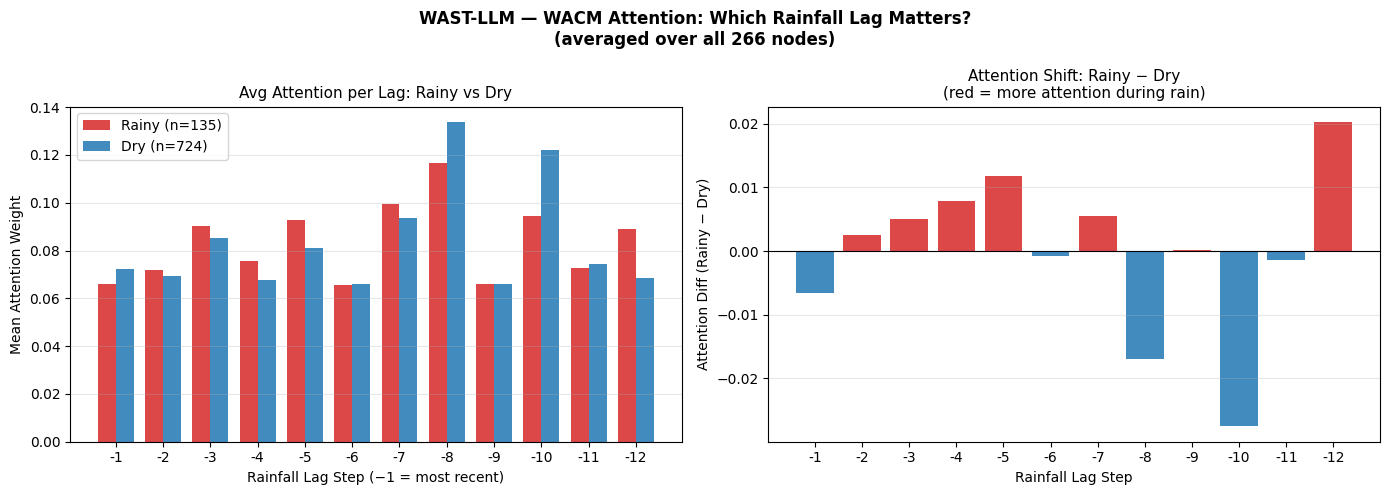

Saved: ./checkpoints/wastllm_attn_lag.png

[Attention per Lag Step]
  Lag     Rainy       Dry      Diff
   -1    0.0659   0.0725   -0.0066
   -2    0.0720   0.0694   +0.0026
   -3    0.0902   0.0852   +0.0050
   -4    0.0755   0.0677   +0.0078
   -5    0.0928   0.0810   +0.0118
   -6    0.0654   0.0662   -0.0007
   -7    0.0993   0.0938   +0.0055
   -8    0.1167   0.1336   -0.0169
   -9    0.0660   0.0659   +0.0001
  -10    0.0946   0.1221   -0.0276
  -11    0.0728   0.0742   -0.0014
  -12    0.0888   0.0685   +0.0203


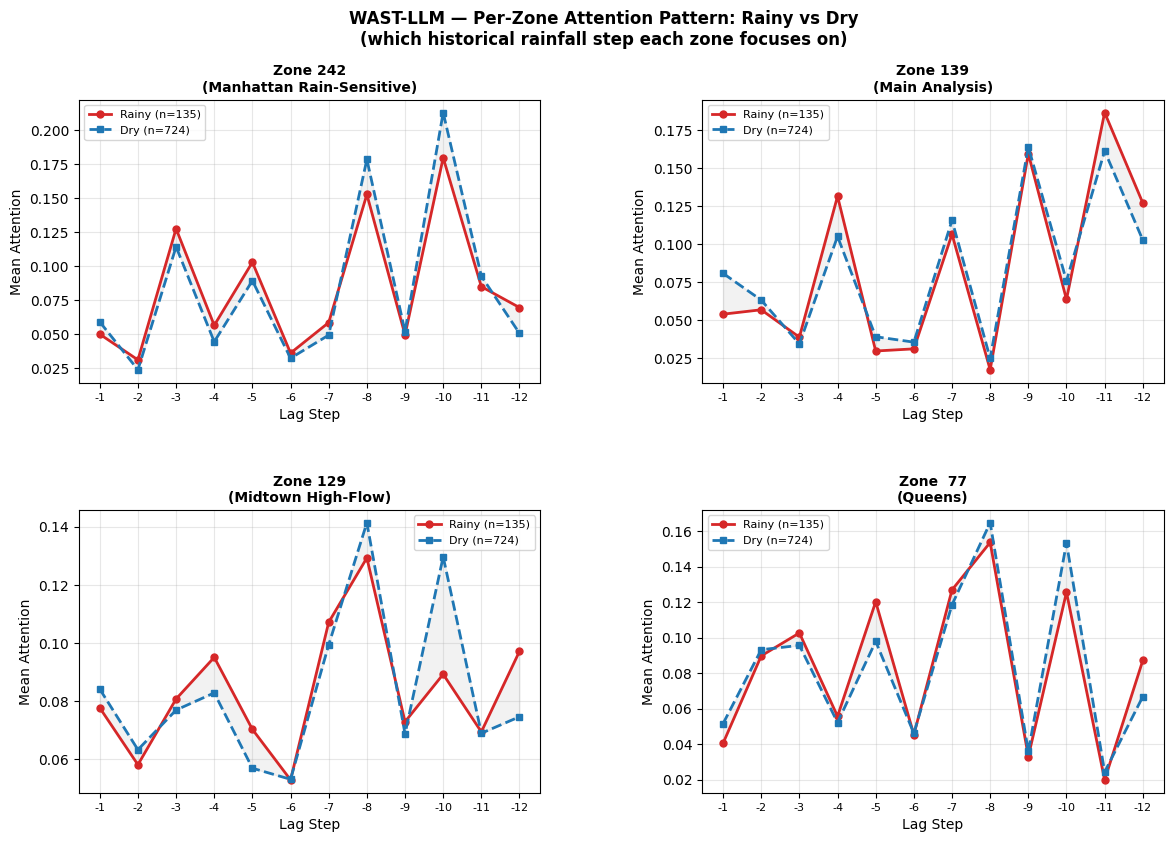

Saved: ./checkpoints/wastllm_attn_per_zone.png


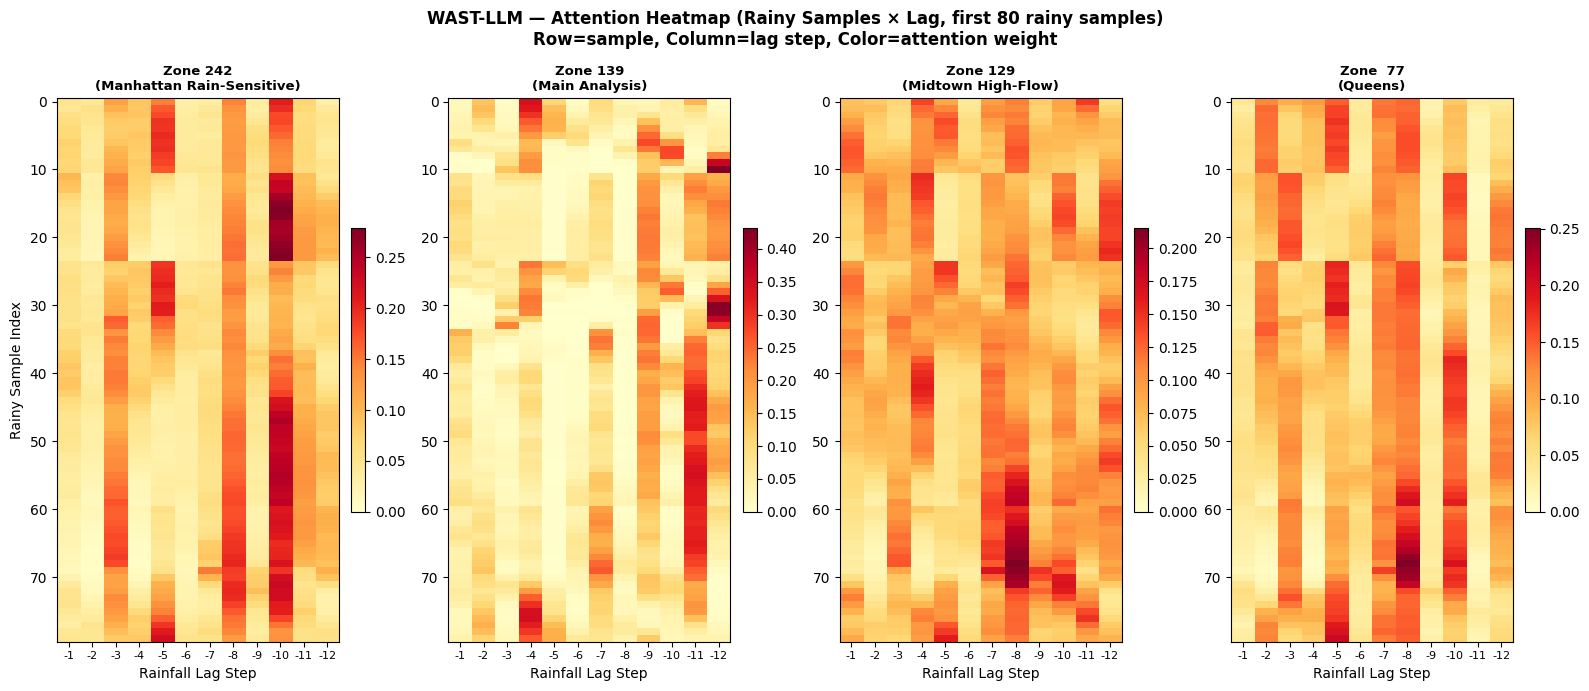

Saved: ./checkpoints/wastllm_attn_heatmap.png

[Per-Zone Attention Summary]
    Zone   MAE(rainy)   TopLag_rain   TopLag_dry
     242        2.2219           -10          -10
     139       22.0553           -11           -9
     129        4.0418            -8           -8
      77        1.8613            -8           -8


In [12]:
# ── Attn 可视化 ───────────────────────────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(313)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size  = 16
num_nodes   = 266
input_len   = 12
output_len  = 12
gpt_layers  = 7
U           = 5
d_weather   = 128
n_embd      = 256
dataset_dir = "w_texi_drop"
CKPT_PATH   = "./checkpoints/best_model.pt"
RAIN_ZONES  = [242, 139, 129, 77]
RAIN_ZONE_LABELS = {
    242: 'Zone 242\n(Manhattan Rain-Sensitive)',
    139: 'Zone 139\n(Main Analysis)',
    129: 'Zone 129\n(Midtown High-Flow)',
     77: 'Zone  77\n(Queens)',
}
n_show = 200

# ── 加载模型 ──────────────────────────────────────────────────────────────────
dataloader = load_dataset(dataset_dir, batch_size=batch_size,
                          valid_batch_size=batch_size, test_batch_size=batch_size)
scaler = dataloader["scaler"]

model = ST_LLM(batch_size=batch_size, num_nodes=num_nodes, n_embd=n_embd,
               input_len=input_len, output_len=output_len,
               gpt_layers=gpt_layers, U=U, d_weather=d_weather).to(device)
state_dict = torch.load(CKPT_PATH, map_location=device)
state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.eval()
print(f"Loaded: {CKPT_PATH}")

# ── 全量推理 ──────────────────────────────────────────────────────────────────
# gate 已去掉（返回 None），用 _ 忽略；attn 正确 append 进列表
all_preds, all_reals, all_rain_cov, all_attns = [], [], [], []

with torch.no_grad():
    for x_batch, y_batch in dataloader["test_loader"]:
        x_batch = x_batch.to(device)
        with torch.cuda.amp.autocast():
            out, w_attn = model(x_batch)   # _ = None（gate 已去掉）

        pred     = scaler.inverse_transform(out).cpu().numpy()       # (B, H, N)
        real     = y_batch.squeeze(-1).numpy()                       # (B, H, N)
        rain_cov = (x_batch[:, :, :, 3] > 0).float().mean(dim=(1, 2)).cpu().numpy()

        # (B*N, H, 1, P) → 多头平均 → reshape → (B, N, P)
        B       = x_batch.shape[0]
        attn_np = w_attn.squeeze(2).mean(dim=1).cpu().numpy().reshape(B, num_nodes, input_len)

        all_preds.append(pred)
        all_reals.append(real)
        all_rain_cov.append(rain_cov)
        all_attns.append(attn_np)          # ← 修复：之前漏掉这一行

preds     = np.concatenate(all_preds,    axis=0)   # (S, H, N)
reals     = np.concatenate(all_reals,    axis=0)   # (S, H, N)
rain_covs = np.concatenate(all_rain_cov, axis=0)   # (S,)
attns     = np.concatenate(all_attns,    axis=0)   # (S, N, P)

print(f"Collected: preds{preds.shape}  attns{attns.shape}")

rainy_mask = rain_covs > 0.1
dry_mask   = rain_covs == 0.0
rainy_idx  = np.where(rainy_mask)[0]

mae_all  = np.mean(np.abs(preds - reals))
mae_rain = np.mean(np.abs(preds[rainy_mask] - reals[rainy_mask])) if rainy_mask.sum() > 0 else float('nan')
mae_dry  = np.mean(np.abs(preds[dry_mask]   - reals[dry_mask]))   if dry_mask.sum()   > 0 else float('nan')
print(f"MAE all={mae_all:.4f}  rainy={mae_rain:.4f}  dry={mae_dry:.4f}")
print(f"Rainy samples: {rainy_mask.sum()}  |  Dry samples: {dry_mask.sum()}")

lag_labels = [f'-{p+1}' for p in range(input_len)]
x_pos      = np.arange(input_len)

# ═══════════════════════════════════════════════════════════════════════════════
# Fig A — Attention per Lag Step: Rainy vs Dry（全节点平均）
# ═══════════════════════════════════════════════════════════════════════════════
attn_rainy_avg = attns[rainy_mask].mean(axis=(0, 1))   # (P,)
attn_dry_avg   = attns[dry_mask].mean(axis=(0, 1))     # (P,)
attn_diff      = attn_rainy_avg - attn_dry_avg

fig_a, axs_a = plt.subplots(1, 2, figsize=(14, 5))
fig_a.suptitle('WAST-LLM — WACM Attention: Which Rainfall Lag Matters?\n'
               '(averaged over all 266 nodes)', fontsize=12, fontweight='bold')

w = 0.38
axs_a[0].bar(x_pos - w/2, attn_rainy_avg, w, color='#d62728', alpha=0.85,
             label=f'Rainy (n={rainy_mask.sum()})')
axs_a[0].bar(x_pos + w/2, attn_dry_avg,   w, color='#1f77b4', alpha=0.85,
             label=f'Dry (n={dry_mask.sum()})')
axs_a[0].set_xticks(x_pos); axs_a[0].set_xticklabels(lag_labels)
axs_a[0].set_xlabel('Rainfall Lag Step (−1 = most recent)')
axs_a[0].set_ylabel('Mean Attention Weight')
axs_a[0].set_title('Avg Attention per Lag: Rainy vs Dry', fontsize=11)
axs_a[0].legend(); axs_a[0].grid(True, alpha=0.3, axis='y')

colors_diff = ['#d62728' if v > 0 else '#1f77b4' for v in attn_diff]
axs_a[1].bar(x_pos, attn_diff, color=colors_diff, alpha=0.85)
axs_a[1].axhline(0, color='black', lw=0.8)
axs_a[1].set_xticks(x_pos); axs_a[1].set_xticklabels(lag_labels)
axs_a[1].set_xlabel('Rainfall Lag Step')
axs_a[1].set_ylabel('Attention Diff (Rainy − Dry)')
axs_a[1].set_title('Attention Shift: Rainy − Dry\n(red = more attention during rain)', fontsize=11)
axs_a[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./checkpoints/wastllm_attn_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./checkpoints/wastllm_attn_lag.png")

print("\n[Attention per Lag Step]")
print(f"{'Lag':>5}  {'Rainy':>8}  {'Dry':>8}  {'Diff':>8}")
for p in range(input_len):
    print(f"  {lag_labels[p]:>3}    {attn_rainy_avg[p]:.4f}   {attn_dry_avg[p]:.4f}   {attn_diff[p]:+.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# Fig B — Per-Zone Attention: Rainy vs Dry（4个区域各自的时滞模式）
# ═══════════════════════════════════════════════════════════════════════════════
fig_b, axs_b = plt.subplots(2, 2, figsize=(14, 9))
fig_b.suptitle('WAST-LLM — Per-Zone Attention Pattern: Rainy vs Dry\n'
               '(which historical rainfall step each zone focuses on)',
               fontsize=12, fontweight='bold')
plt.subplots_adjust(hspace=0.45, wspace=0.35)

for ax, zone_id in zip(axs_b.flat, RAIN_ZONES):
    zone_rainy = attns[rainy_mask, zone_id, :].mean(axis=0)
    zone_dry   = attns[dry_mask,   zone_id, :].mean(axis=0)
    ax.plot(x_pos, zone_rainy, color='#d62728', lw=2, marker='o', ms=5,
            label=f'Rainy (n={rainy_mask.sum()})')
    ax.plot(x_pos, zone_dry,   color='#1f77b4', lw=2, marker='s', ms=5, ls='--',
            label=f'Dry (n={dry_mask.sum()})')
    ax.fill_between(x_pos, zone_rainy, zone_dry, alpha=0.1, color='gray')
    ax.set_xticks(x_pos); ax.set_xticklabels(lag_labels, fontsize=8)
    ax.set_xlabel('Lag Step'); ax.set_ylabel('Mean Attention')
    ax.set_title(RAIN_ZONE_LABELS[zone_id], fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.savefig('./checkpoints/wastllm_attn_per_zone.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./checkpoints/wastllm_attn_per_zone.png")

# ═══════════════════════════════════════════════════════════════════════════════
# Fig C — Attention Heatmap（雨天样本 × 时滞，4个区域）
# ═══════════════════════════════════════════════════════════════════════════════
n_heatmap = min(80, len(rainy_idx))
heat_idx  = rainy_idx[:n_heatmap]

fig_c, axs_c = plt.subplots(1, len(RAIN_ZONES), figsize=(16, 7))
fig_c.suptitle(f'WAST-LLM — Attention Heatmap (Rainy Samples × Lag, first {n_heatmap} rainy samples)\n'
               'Row=sample, Column=lag step, Color=attention weight',
               fontsize=12, fontweight='bold')

for ax, zone_id in zip(axs_c, RAIN_ZONES):
    heat_data = attns[heat_idx, zone_id, :]
    im = ax.imshow(heat_data, aspect='auto', cmap='YlOrRd',
                   origin='upper', vmin=0, vmax=heat_data.max())
    ax.set_xticks(range(input_len)); ax.set_xticklabels(lag_labels, fontsize=8)
    ax.set_xlabel('Rainfall Lag Step')
    ax.set_ylabel('Rainy Sample Index' if zone_id == RAIN_ZONES[0] else '')
    ax.set_title(RAIN_ZONE_LABELS[zone_id], fontsize=9.5, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('./checkpoints/wastllm_attn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./checkpoints/wastllm_attn_heatmap.png")

# ── 打印各区域注意力摘要 ──────────────────────────────────────────────────────
print("\n[Per-Zone Attention Summary]")
print(f"{'Zone':>8}  {'MAE(rainy)':>11}  {'TopLag_rain':>12}  {'TopLag_dry':>11}")
for zone_id in RAIN_ZONES:
    t_z   = reals[rainy_idx, 0, zone_id]
    p_z   = preds[rainy_idx, 0, zone_id]
    m_mae = np.mean(np.abs(p_z - t_z))
    top_r = lag_labels[attns[rainy_mask, zone_id, :].mean(axis=0).argmax()]
    top_d = lag_labels[attns[dry_mask,   zone_id, :].mean(axis=0).argmax()] if dry_mask.sum() > 0 else 'N/A'
    print(f"  {zone_id:>6}   {m_mae:>11.4f}  {top_r:>12}  {top_d:>11}")
